# TUGAS MACHINE LEARNING
# Topik: Sampling dan Exploratory Data Analysis (EDA)
# Dataset: Iris

Berlian Mumtajmia Lahudin
2304010027

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

# Mengatur tampilan grafik
sns.set(style="whitegrid")

A. EXPLORATORY DATA ANALYSIS (EDA)

# LOAD DATASET IRIS

In [3]:
iris = load_iris()

# Mengubah dataset menjadi DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Menambahkan kolom spesies
df["species"] = iris.target
df["species"] = df["species"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

# Menampilkan data awal
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# INFORMASI DATASET


In [4]:

print("Jumlah data:", df.shape[0])
print("Jumlah variabel:", df.shape[1])

print("\nTipe data tiap variabel:")
df.dtypes

Jumlah data: 150
Jumlah variabel: 5

Tipe data tiap variabel:


,0
sepal length (cm),float64
sepal width (cm),float64
petal length (cm),float64
petal width (cm),float64
species,object


In [5]:
# Jumlah masing-masing spesies
df["species"].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


# STATISTIK DESKRIPTIF

Statistik deskriptif digunakan untuk melihat gambaran umum data Iris,
meliputi jumlah data, nilai rata-rata (mean), standar deviasi, nilai minimum,
dan maksimum dari setiap variabel numerik.

In [21]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [23]:
df.median(numeric_only=True)

,0
sepal length (cm),5.80
sepal width (cm),3.00
petal length (cm),4.35
petal width (cm),1.30


# HISTOGRAM VARIABEL NUMERIK

Histogram digunakan untuk melihat bentuk distribusi data pada setiap variabel numerik.

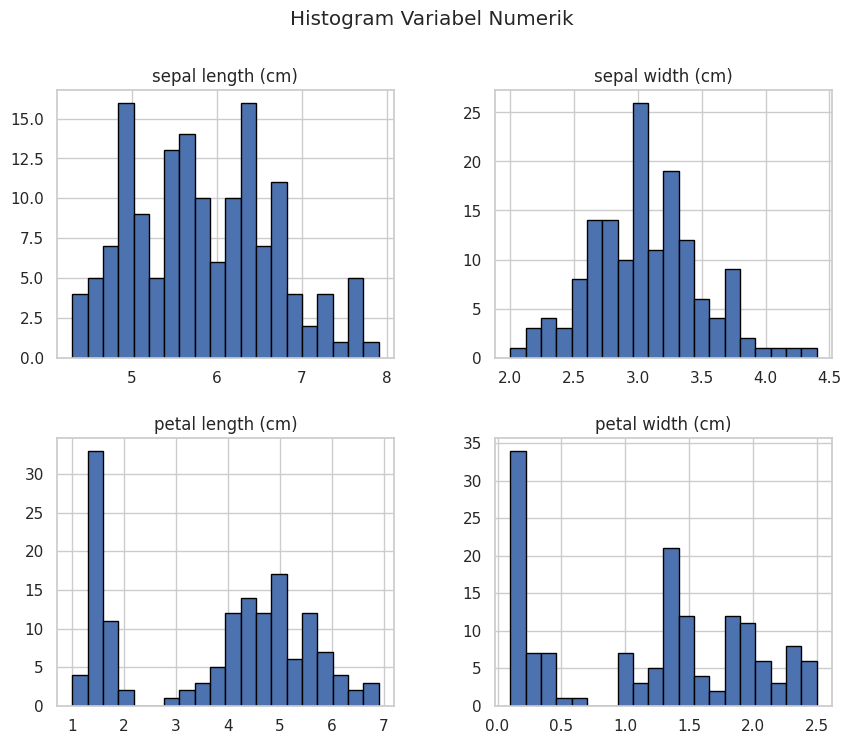

In [7]:
num_cols = iris.feature_names

df[num_cols].hist(
    figsize=(10, 8),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Histogram Variabel Numerik")
plt.show()

# BOXPLOT VARIABEL NUMERIK

Boxplot digunakan untuk melihat sebaran data, nilai tengah (median), dan outlier.

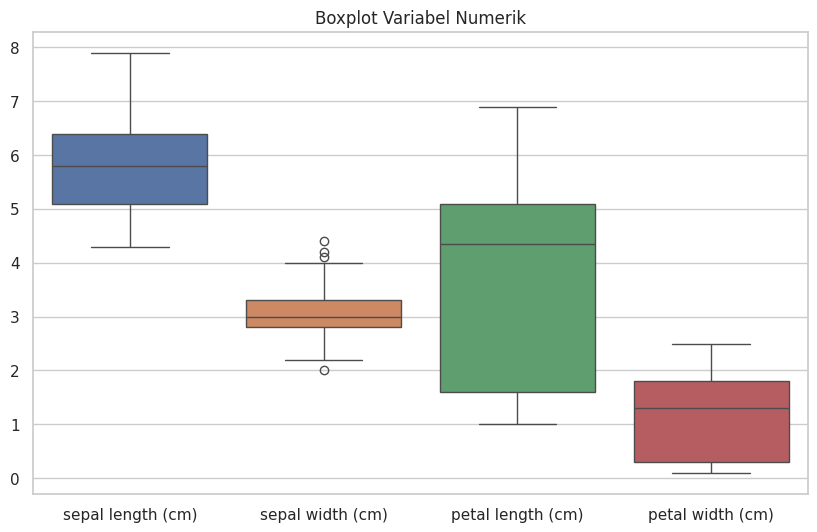

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[num_cols])
plt.title("Boxplot Variabel Numerik")
plt.show()

# BOXPLOT PETAL LENGTH PER SPESIES

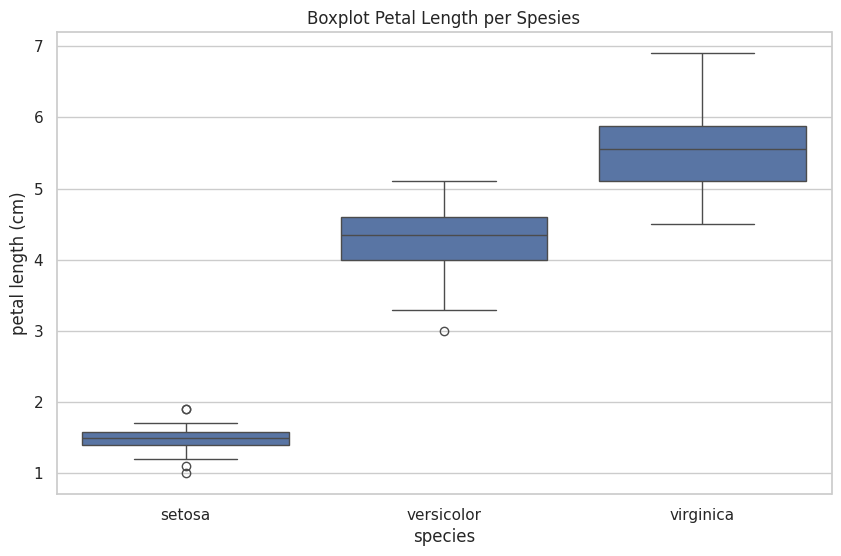

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    x="species",
    y="petal length (cm)",
    data=df
)
plt.title("Boxplot Petal Length per Spesies")
plt.show()

B. BOOTSTRAP SAMPLING

# BOOTSTRAP TUNGGAL

In [10]:
np.random.seed(42)

petal_length = df["petal length (cm)"]

bootstrap_sample = np.random.choice(
    petal_length,
    size=len(petal_length),
    replace=True
)

print("Mean data asli:", petal_length.mean())
print("Median data asli:", petal_length.median())
print("Mean bootstrap:", bootstrap_sample.mean())
print("Median bootstrap:", np.median(bootstrap_sample))

Mean data asli: 3.7580000000000005
Median data asli: 4.35
Mean bootstrap: 3.734666666666667
Median bootstrap: 4.2


# FUNGSI BOOTSTRAP BERULANG

In [11]:
def bootstrap_mean(data, jumlah_bootstrap):
    hasil_mean = []
    for _ in range(jumlah_bootstrap):
        sampel = np.random.choice(
            data,
            size=len(data),
            replace=True
        )
        hasil_mean.append(sampel.mean())
    return np.array(hasil_mean)

# MENJALANKAN BOOTSTRAP

In [12]:
bootstrap_100 = bootstrap_mean(petal_length, 100)
bootstrap_1000 = bootstrap_mean(petal_length, 1000)
bootstrap_10000 = bootstrap_mean(petal_length, 10000)

# HISTOGRAM MEAN BOOTSTRAP

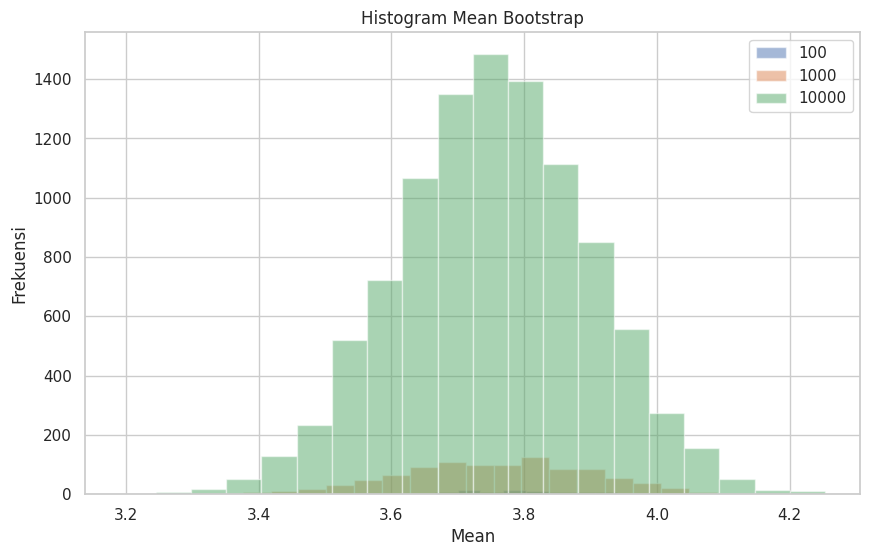

In [13]:
plt.figure(figsize=(10, 6))
plt.hist(bootstrap_100, bins=20, alpha=0.5, label="100")
plt.hist(bootstrap_1000, bins=20, alpha=0.5, label="1000")
plt.hist(bootstrap_10000, bins=20, alpha=0.5, label="10000")
plt.legend()
plt.title("Histogram Mean Bootstrap")
plt.xlabel("Mean")
plt.ylabel("Frekuensi")
plt.show()

# BOXPLOT MEAN BOOTSTRAP

/tmp/ipython-input-151/2679790876.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


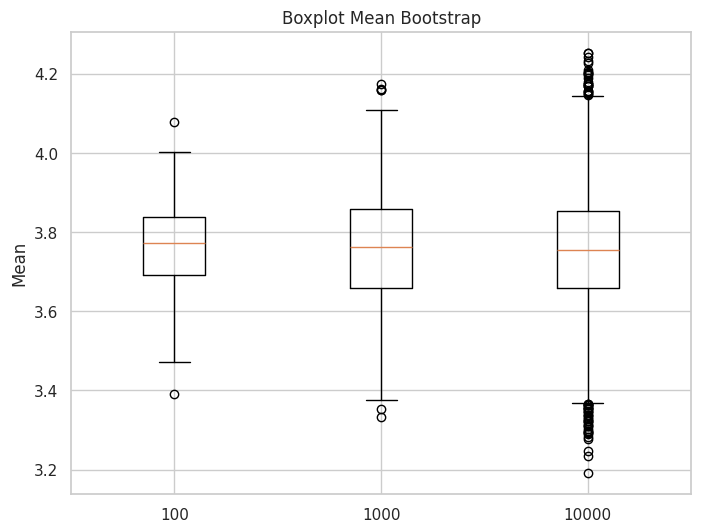

In [14]:
plt.figure(figsize=(8, 6))
plt.boxplot(
    [bootstrap_100, bootstrap_1000, bootstrap_10000],
    labels=["100", "1000", "10000"]
)
plt.title("Boxplot Mean Bootstrap")
plt.ylabel("Mean")
plt.show()

In [17]:
mean_asli = petal_length.mean()

print("Mean data asli:", mean_asli)

Mean data asli: 3.7580000000000005


# INTERVAL KEPERCAYAAN 95%

In [18]:
def interval_kepercayaan(data):
    batas_bawah = np.percentile(data, 2.5)
    batas_atas = np.percentile(data, 97.5)
    return batas_bawah, batas_atas

ci_100 = interval_kepercayaan(bootstrap_100)
ci_1000 = interval_kepercayaan(bootstrap_1000)
ci_10000 = interval_kepercayaan(bootstrap_10000)

print("CI 95% Bootstrap 100 :", ci_100)
print("CI 95% Bootstrap 1000:", ci_1000)
print("CI 95% Bootstrap 10000:", ci_10000)

CI 95% Bootstrap 100 : (np.float64(3.5123333333333338), np.float64(3.99135))
CI 95% Bootstrap 1000: (np.float64(3.4793166666666666), np.float64(4.029416666666666))
CI 95% Bootstrap 10000: (np.float64(3.4693166666666673), np.float64(4.034666666666666))


C. ANALISIS & PERBANDINGAN

# ANALISIS HASIL

In [24]:
print("Mean asli dalam CI 100? :", ci_100[0] <= mean_asli <= ci_100[1])
print("Mean asli dalam CI 1000?:", ci_1000[0] <= mean_asli <= ci_1000[1])
print("Mean asli dalam CI 10000?:", ci_10000[0] <= mean_asli <= ci_10000[1])

Mean asli dalam CI 100? : True
Mean asli dalam CI 1000?: True
Mean asli dalam CI 10000?: True


1. Apakah mean bootstrap mendekati mean data asli?

Ya. Mean bootstrap mendekati mean data asli. Hal ini dibuktikan dengan mean data asli yang selalu berada di dalam interval kepercayaan 95%.

2. Bagaimana perubahan distribusi saat jumlah bootstrap bertambah?

Semakin banyak jumlah bootstrap, distribusi mean menjadi lebih rapat dan stabil.

3. Mana yang lebih stabil: 100, 1000, atau 10000?
Bootstrap 10000 paling stabil karena variasinya paling kecil.

4. Apakah mean data asli berada dalam interval kepercayaan?

Ya. Mean data asli berada dalam interval kepercayaan 95% untuk bootstrap 100, 1000, dan 10000.

5. Mengapa satu data bisa muncul berkali-kali pada bootstrap?

Karena bootstrap menggunakan sampling dengan pengembalian, sehingga satu data bisa terpilih lebih dari satu kali.

D. Kesimpulan



**Insight utama dari EDA dataset Iris**
Dataset Iris terbukti memiliki kualitas data yang baik — bersih, seimbang, dan bebas dari nilai yang hilang. Fitur petal menunjukkan variasi yang jauh lebih tinggi dibandingkan fitur sepal, menjadikannya lebih efektif dalam membedakan satu spesies bunga Iris dengan lainnya.

**Karakteristik tiap spesies (berdasarkan visualisasi)**
* Setosa dikenal dengan ukuran petal yang paling kecil serta persebaran data yang cenderung sempit dan terpusat.
* Versicolor menempati posisi tengah dengan ukuran petal yang sedang, berada di antara kedua spesies lainnya.
* Virginica memiliki petal berukuran paling besar dengan sebaran data yang lebih luas dan beragam.

Perbedaan paling mencolok antara ketiga spesies dapat diamati melalui variabel petal length dan petal width.

**Manfaat bootstrap dalam analisis data**
Metode bootstrap berguna untuk memperkirakan parameter statistik seperti nilai rata-rata, tanpa perlu mengandalkan asumsi tertentu mengenai distribusi data. Selain itu, metode ini memungkinkan kita untuk menilai kestabilan hasil estimasi serta menyusun interval kepercayaan dari data yang ada.

**Jumlah bootstrap yang menurut saya cukup**
Menurut pandangan saya, penggunaan bootstrap sebanyak 1.000 hingga 10.000 iterasi sudah memadai, karena mampu menghasilkan estimasi rata-rata yang stabil dan interval kepercayaan yang lebih presisi dibandingkan dengan jumlah iterasi yang lebih sedikit.